In [1]:
import json
from datetime import timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from bisect import bisect_right  
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize

import importlib
import obspy
from obspy import read, UTCDateTime, Stream
from obspy.core.util import AttribDict
from obspy.geodetics.base import gps2dist_azimuth
from obspy.imaging.cm import obspy_sequential
from obspy.signal.array_analysis import array_processing
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees

In [2]:
from pathlib import Path
import sys, importlib

import pandas as pd
from obspy import UTCDateTime

#  qq_helpers.py
HELPERS_DIR = "/home/elizabeth/soft/src/QuickQuake/quickquake"
if HELPERS_DIR not in sys.path:
    sys.path.insert(0, HELPERS_DIR)

import qq_helpers as h
importlib.reload(h)   # reload qq_helpers.py
print("helpers:", h.__file__)


helpers: /home/elizabeth/soft/src/QuickQuake/quickquake/qq_helpers.py


In [3]:
# Paths
DATA_ROOT = Path("/home/elizabeth/soft/src/QuickQuake/data")
CATALOG_CSV   = DATA_ROOT / "merged/output/GAMMA_hypodd_catalog.csv"
#CATALOG_CSV   = DATA_ROOT / "merged/input/GAMMA_catalog_cleaned.csv"

PICKS_CSV     = DATA_ROOT / "merged/input/GAMMA_picks_cleaned.csv"
STATIONS_JSON = DATA_ROOT / "merged/input/GAMMA_station_list.json"

catalog, picks, stations = h.load_inputs(CATALOG_CSV, PICKS_CSV, STATIONS_JSON)
print("Loaded:", catalog.shape, picks.shape, stations.shape)


Loaded: (57, 6) (1250, 9) (11, 4)


In [4]:
# Waveform index + cache
INDEX_PATH = Path("/home/elizabeth/soft/src/QuickQuake/waveform_index.pkl")

if INDEX_PATH.exists():
    wf_index = h.WaveformIndex.load(INDEX_PATH)
else:
    wf_index = h.WaveformIndex.build([DATA_ROOT], glob_pattern="**/waveforms/*.mseed")
    wf_index.save(INDEX_PATH)

cache = h.StreamCache()
print("Indexed mseed files:", len(wf_index.df))


Indexed mseed files: 2


In [5]:
# check 
print("Catalog time min/max:", catalog["datetime"].min(), catalog["datetime"].max())
print("Waveforms time min/max:",
      pd.to_datetime(wf_index.df["t0"], unit="s", utc=True).min(),
      pd.to_datetime(wf_index.df["t1"], unit="s", utc=True).max())


Catalog time min/max: 2021-07-29 08:03:26.930000+00:00 2021-07-29 23:38:44.800000+00:00
Waveforms time min/max: 2021-07-29 08:00:00+00:00 2021-07-30 00:00:00+00:00


MOVEOUT PLOT

0 files: ['2021-07-29T08-00-00.mseed', '2021-07-29T16-00-00.mseed'] stations: 7


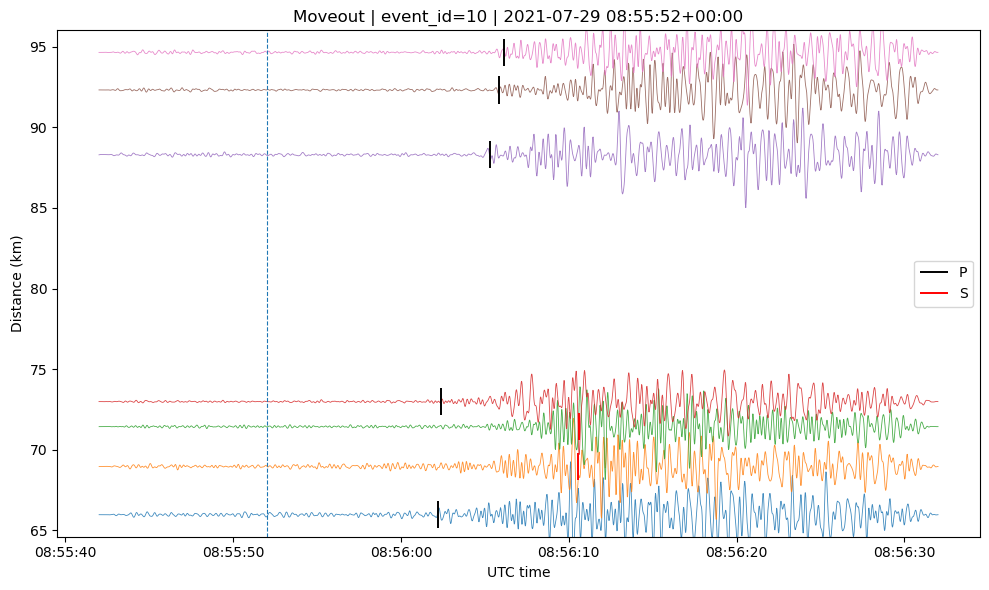

In [6]:
# Plot 
for i, row in catalog.iloc[0:1].iterrows():
    fig, ax, meta = h.plot_event_moveout_picks_only(
        row_event=row,
        picks=picks,
        stations=stations,
        cache=cache,
        wf_index=wf_index,
        pre_s=10,
        post_s=40,
        freqmin=1.0,
        freqmax=5.0,
        p_color="black",
        s_color="red",
        line_height_km=1.7,
        line_width=1.4,
        wiggle_frac_of_spacing=1.2,
    )

    print(i, "files:", [Path(f).name for f in meta["files"]], "stations:", len(meta["stations_used"]))


SPECTROGRAM

/home/elizabeth/soft/src/QuickQuake/quickquake/qq_helpers.py:992: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



files: ['2021-07-29T08-00-00.mseed', '2021-07-29T16-00-00.mseed']
stations used: 7


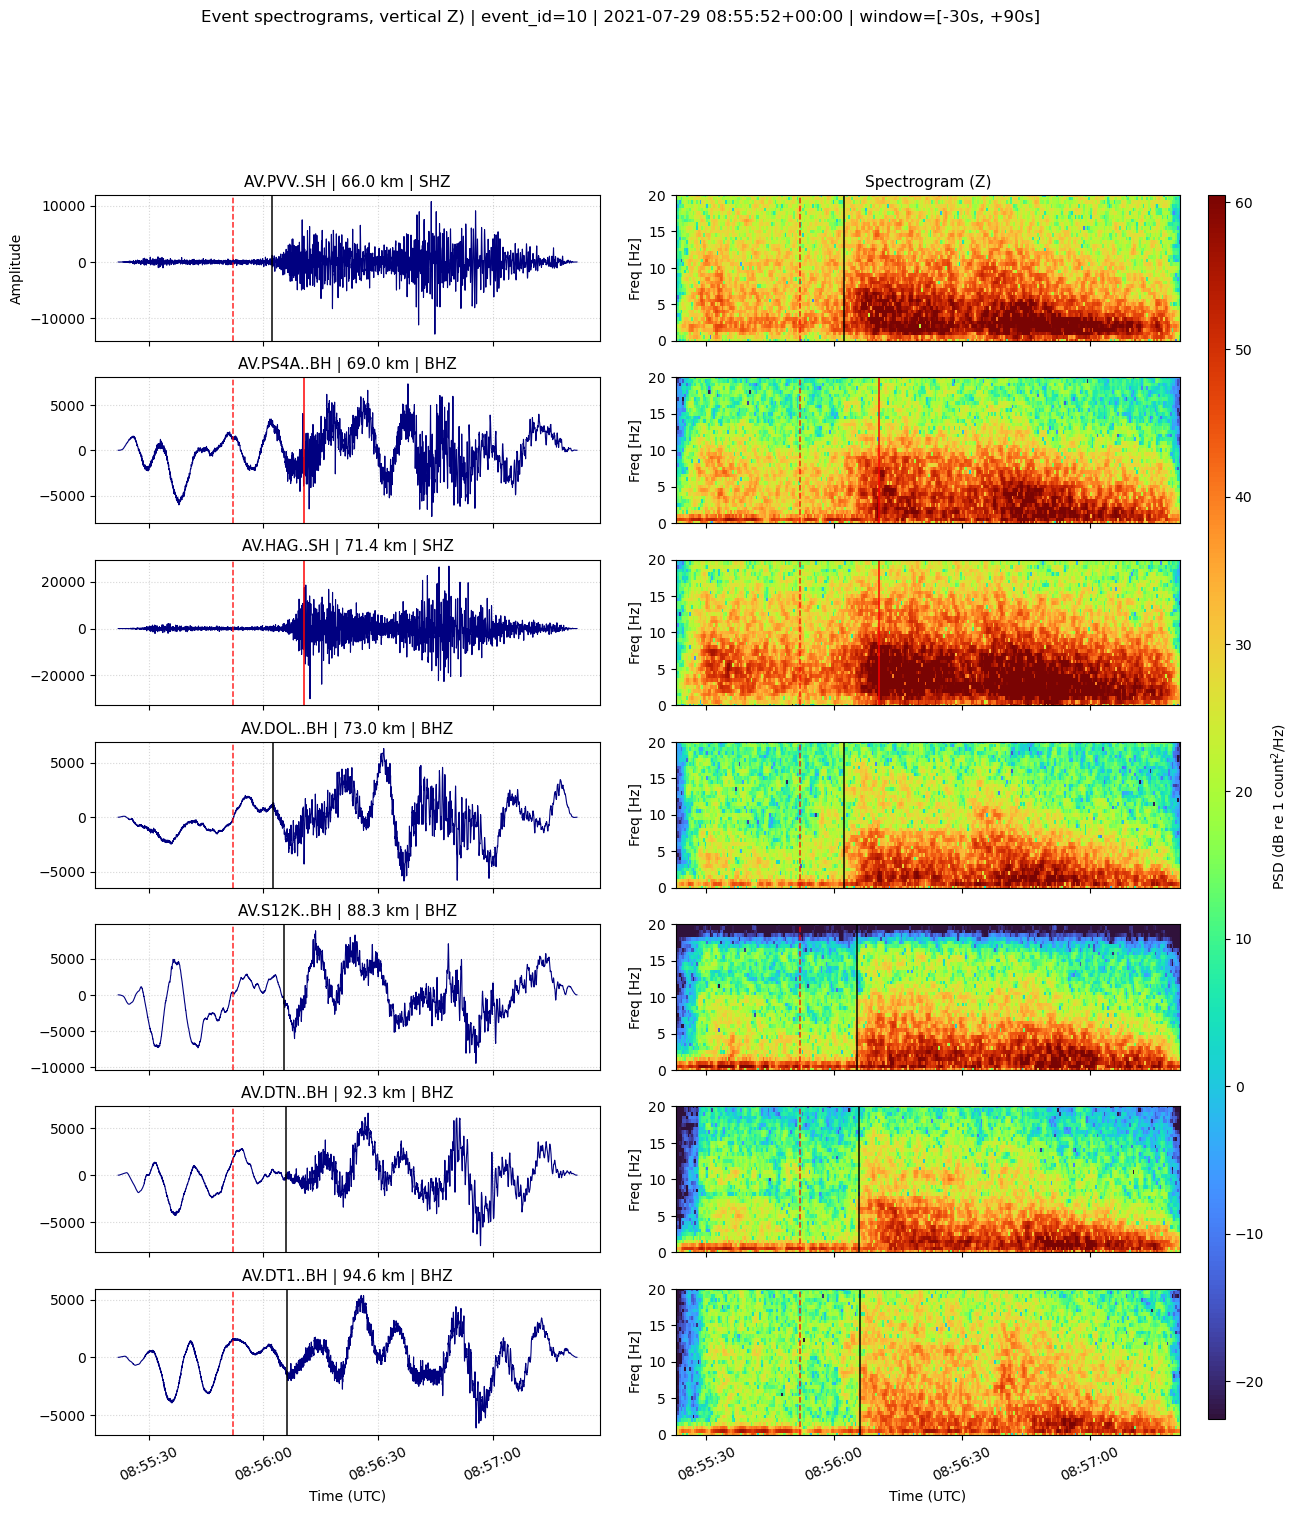

In [30]:
for i, row in catalog.iloc[0:1].iterrows():

    fig, axes, meta = h.plot_event_spectrograms_vertical_picks_only(
        row_event=row,
        picks=picks,
        stations=stations,
        cache=cache,
        wf_index=wf_index,
        pre_s=30,
        post_s=90,
        window_s=2,
        overlap_frac=0.8,
        freq_min=0,
        freq_max=20,
        # optional
        # bp_freqmin=1.0,
        # bp_freqmax=10.0,
    )

    print("files:", [Path(f).name for f in meta["files"]])
    print("stations used:", len(meta["stations_used"]))


In [17]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"   # o "vscode" si estás en VSCode

fig = h.plot_catalog_3d_topo_seismicity(
    catalog=catalog,
    mode="time",
    show=True,   
)



/home/elizabeth/anaconda3/envs/seisgo/lib/python3.9/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.


grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -161.841878 to -161.845833333
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -160.696973 to -160.695833333
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 55.07915 to 55.075
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 55.410071 to 55.4125


In [23]:
fig = h.plot_catalog_3d_topo_seismicity(
    catalog=catalog,
    mode="year_month",
    year=2021,
    show=True,
)


grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -162.401 to -162.404166667
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -161.371 to -161.370833333
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 54.903 to 54.9
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 55.696 to 55.7
